In [12]:
import pandas as pd
import glob

# List of files
files = [
    'api_data_aadhar_enrolment_0_500000.csv',
    'api_data_aadhar_enrolment_500000_1000000.csv',
    'api_data_aadhar_enrolment_1000000_1006029.csv'
]

# Load and concatenate
dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

# Basic Inspection
print("Data Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Data Shape: (1006029, 7)

First 5 rows:
         date          state          district  pincode  age_0_5  age_5_17  \
0  02-03-2025      Meghalaya  East Khasi Hills   793121       11        61   
1  09-03-2025      Karnataka   Bengaluru Urban   560043       14        33   
2  09-03-2025  Uttar Pradesh      Kanpur Nagar   208001       29        82   
3  09-03-2025  Uttar Pradesh           Aligarh   202133       62        29   
4  09-03-2025      Karnataka   Bengaluru Urban   560016       14        16   

   age_18_greater  
0              37  
1              39  
2              12  
3              15  
4              21  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006029 entries, 0 to 1006028
Data columns (total 7 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   date            1006029 non-null  object
 1   state           1006029 non-null  object
 2   district        1006029 non-null  object
 3   pincode     

Monthly Trends:
 month
2025-03      16582
2025-04     257438
2025-05     183616
2025-06     215734
2025-07     616868
2025-09    1475879
2025-10     817920
2025-11    1092007
2025-12     759658
Freq: M, Name: total_enrolments, dtype: int64

Top 5 States:
 state
Uttar Pradesh     1018629
Bihar              609585
Madhya Pradesh     493970
West Bengal        375297
Maharashtra        369139
Name: total_enrolments, dtype: int64

Total Demographics:
 age_0_5           3546965
age_5_17          1720384
age_18_greater     168353
dtype: int64


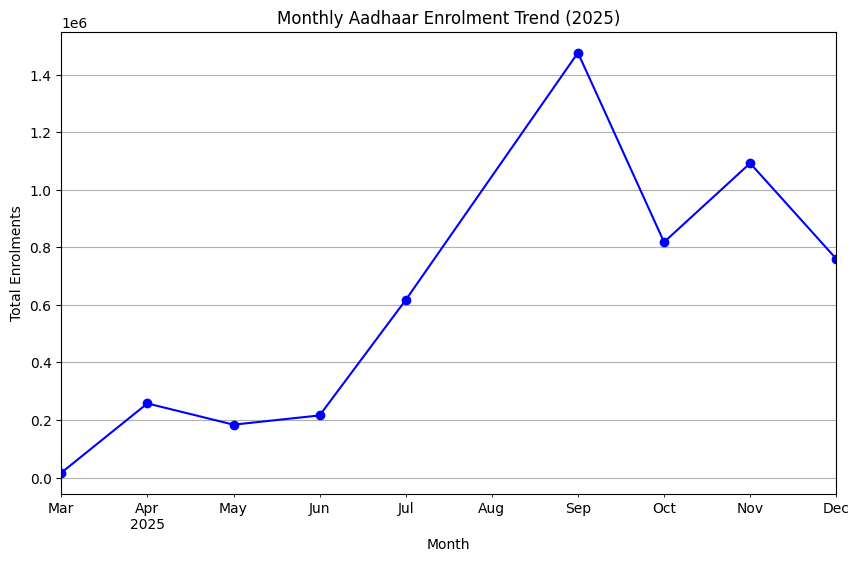

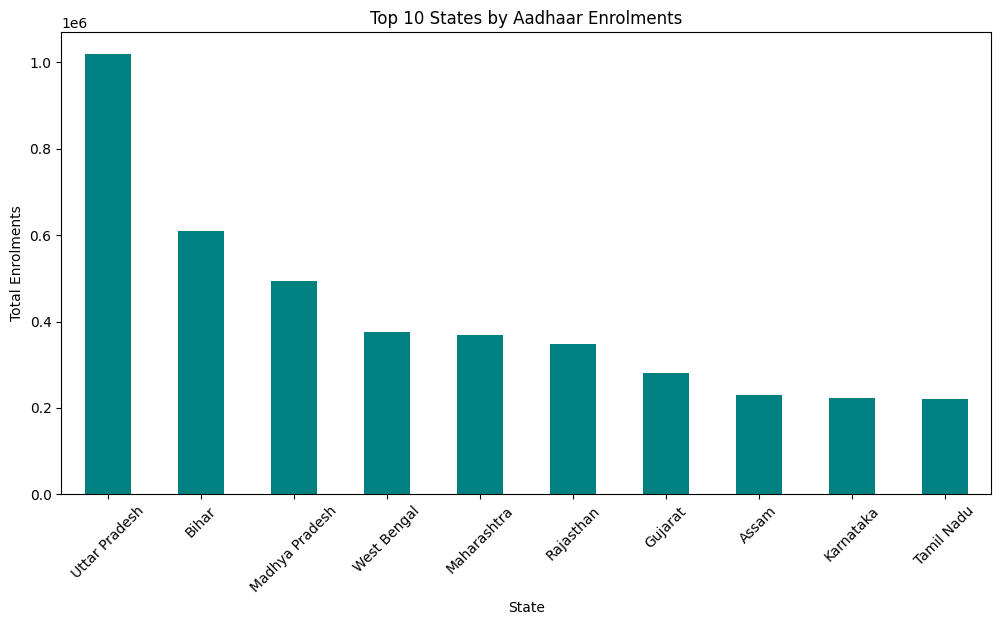

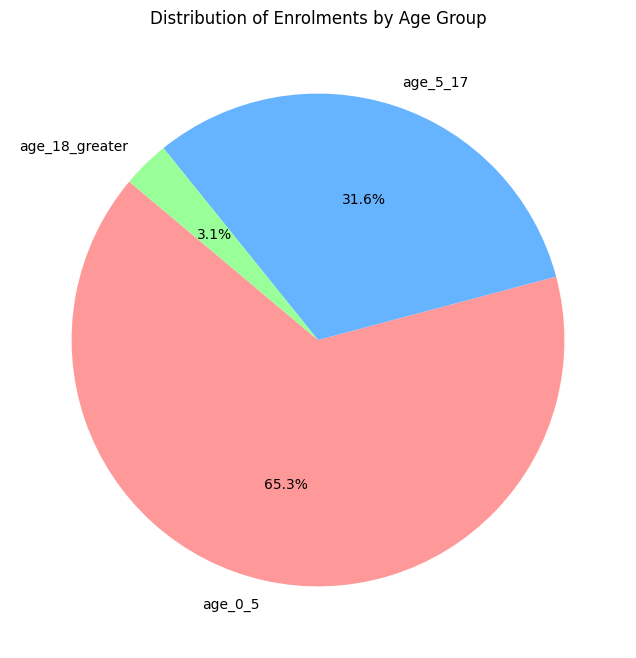

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date to datetime
df['date'] = pd.to_datetime(df["date"], format="%d-%m-%Y")

df['month'] = df['date'].dt.to_period('M')

# Total enrolments
df['total_enrolments'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']

# 1. Temporal Trend - Monthly Total Enrolments
monthly_trend = df.groupby('month')['total_enrolments'].sum()

# 2. State-wise Total Enrolments
state_enrolments = df.groupby('state')['total_enrolments'].sum().sort_values(ascending=False)

# 3. Demographic distribution
demographics = df[['age_0_5', 'age_5_17', 'age_18_greater']].sum()

# Plotting Trends
# Monthly Trend
plt.figure(figsize=(10, 6))
monthly_trend.plot(kind='line', marker='o', color='b')
plt.title('Monthly Aadhaar Enrolment Trend (2025)')
plt.xlabel('Month')
plt.ylabel('Total Enrolments')
plt.grid(True)
plt.savefig('monthly_trend.png')

# State-wise Enrolments (Top 10)
plt.figure(figsize=(12, 6))
state_enrolments.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 States by Aadhaar Enrolments')
plt.xlabel('State')
plt.ylabel('Total Enrolments')
plt.xticks(rotation=45)
plt.savefig('top_states.png')

# Demographic Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(demographics, labels=demographics.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribution of Enrolments by Age Group')
plt.savefig('demographics_pie.png')

print("Monthly Trends:\n", monthly_trend)
print("\nTop 5 States:\n", state_enrolments.head(5))
print("\nTotal Demographics:\n", demographics)

Monthly Trends:
 month
2025-03      16582
2025-04     257438
2025-05     183616
2025-06     215734
2025-07     616868
2025-09    1475879
2025-10     817920
2025-11    1092007
2025-12     759658
Freq: M, Name: total_enrolments, dtype: int64

Top 5 States:
 state
Uttar Pradesh     1018629
Bihar              609585
Madhya Pradesh     493970
West Bengal        375297
Maharashtra        369139
Name: total_enrolments, dtype: int64

Total Demographics:
 age_0_5           3546965
age_5_17          1720384
age_18_greater     168353
dtype: int64


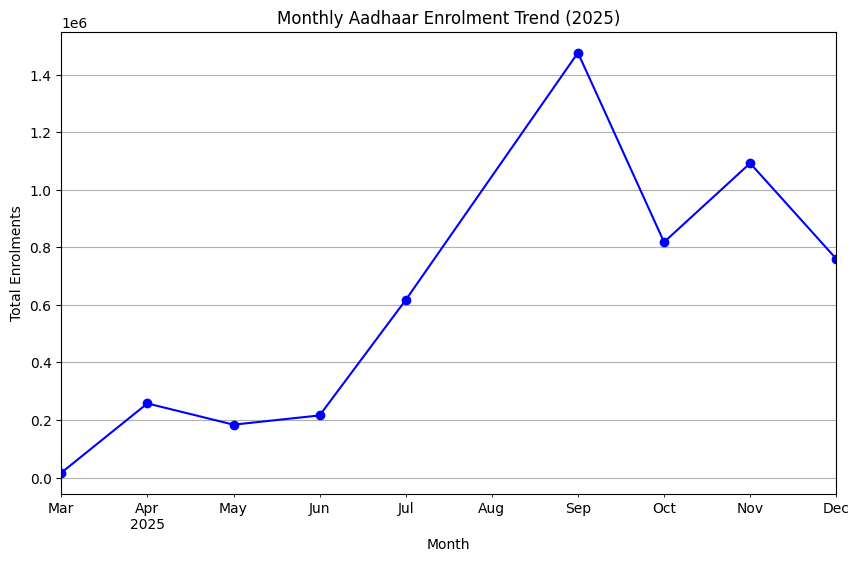

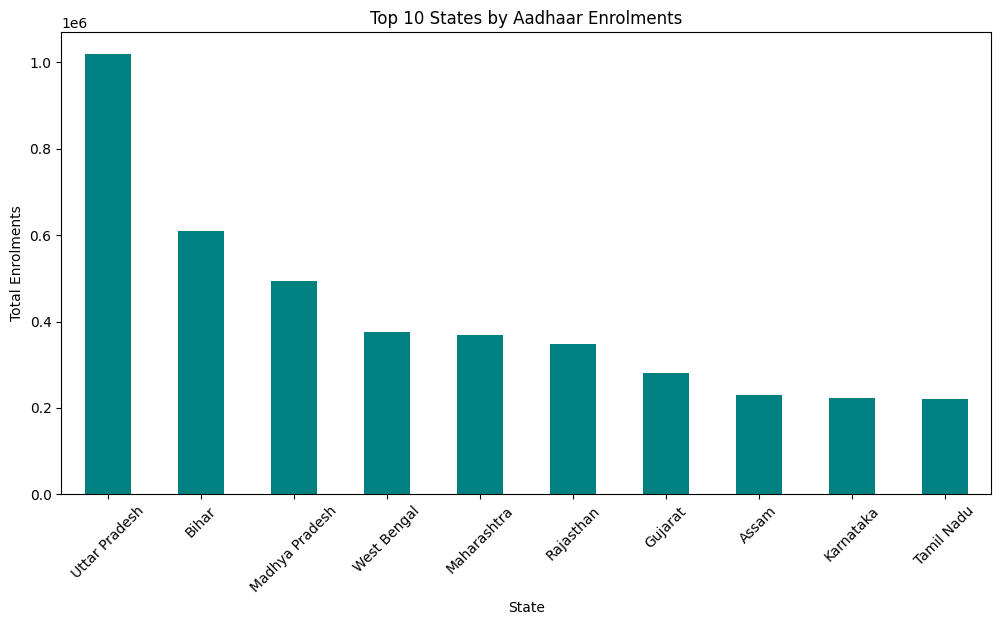

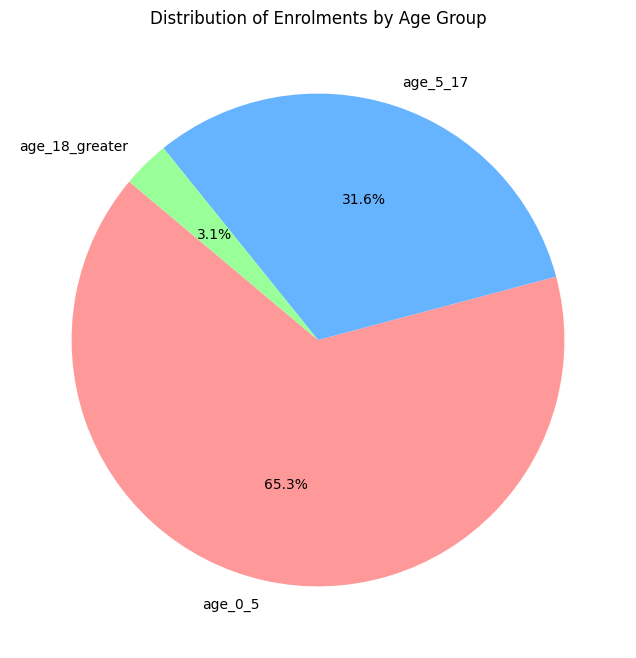

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%reset_index')
df['month'] = df['date'].dt.to_period('M')

# Total enrolments
df['total_enrolments'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']

# 1. Temporal Trend - Monthly Total Enrolments
monthly_trend = df.groupby('month')['total_enrolments'].sum()

# 2. State-wise Total Enrolments
state_enrolments = df.groupby('state')['total_enrolments'].sum().sort_values(ascending=False)

# 3. Demographic distribution
demographics = df[['age_0_5', 'age_5_17', 'age_18_greater']].sum()

# Plotting Trends
# Monthly Trend
plt.figure(figsize=(10, 6))
monthly_trend.plot(kind='line', marker='o', color='b')
plt.title('Monthly Aadhaar Enrolment Trend (2025)')
plt.xlabel('Month')
plt.ylabel('Total Enrolments')
plt.grid(True)
plt.savefig('monthly_trend.png')

# State-wise Enrolments (Top 10)
plt.figure(figsize=(12, 6))
state_enrolments.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 States by Aadhaar Enrolments')
plt.xlabel('State')
plt.ylabel('Total Enrolments')
plt.xticks(rotation=45)
plt.savefig('top_states.png')

# Demographic Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(demographics, labels=demographics.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribution of Enrolments by Age Group')
plt.savefig('demographics_pie.png')

print("Monthly Trends:\n", monthly_trend)
print("\nTop 5 States:\n", state_enrolments.head(5))
print("\nTotal Demographics:\n", demographics)

Monthly Trends:
 month
2025-03      16582
2025-04     257438
2025-05     183616
2025-06     215734
2025-07     616868
2025-09    1475879
2025-10     817920
2025-11    1092007
2025-12     759658
Freq: M, Name: total_enrolments, dtype: int64

Top 5 States:
 state
Uttar Pradesh     1018629
Bihar              609585
Madhya Pradesh     493970
West Bengal        375297
Maharashtra        369139
Name: total_enrolments, dtype: int64

Demographic Sums:
 age_0_5           3546965
age_5_17          1720384
age_18_greater     168353
dtype: int64

Potential Anomalous Records (Highest single-day/pincode enrolments):
           date           state          district  pincode  total_enrolments
2976 2025-07-01   Uttar Pradesh         Moradabad   244001              3965
3213 2025-07-01     Maharashtra        Aurangabad   431001              3835
893  2025-04-01       Meghalaya  West Khasi Hills   793119              3027
3041 2025-07-01   Uttar Pradesh            Hardoi   241001              3006
2446 

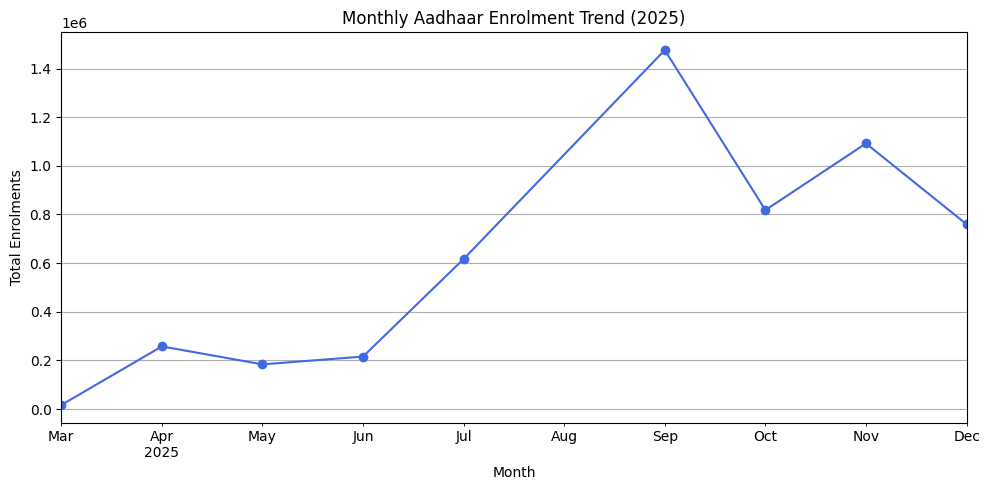

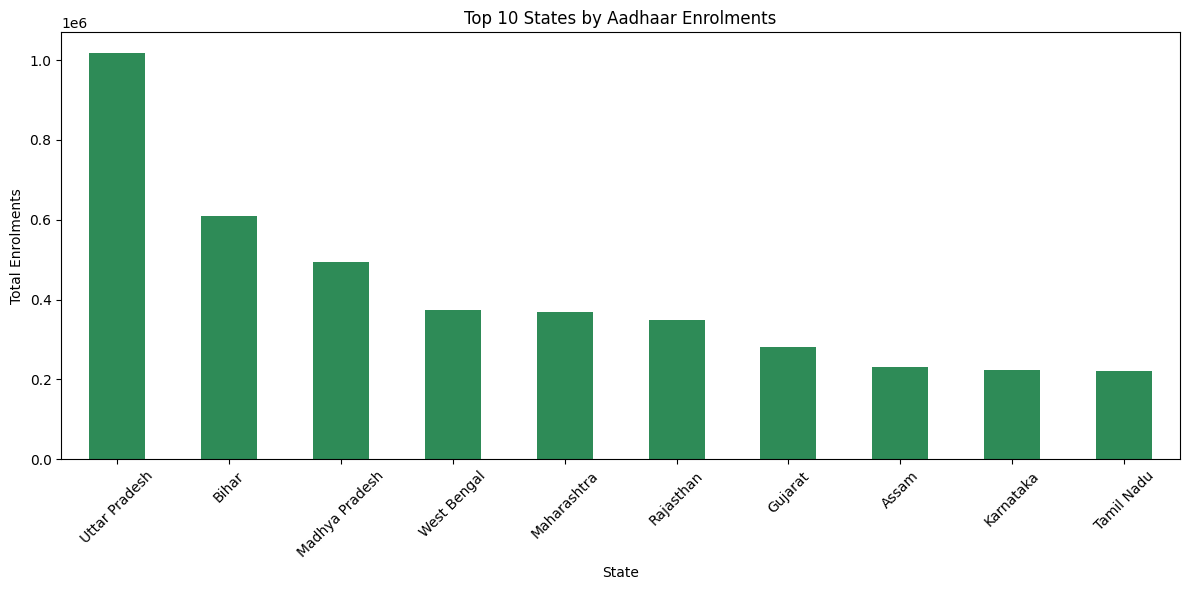

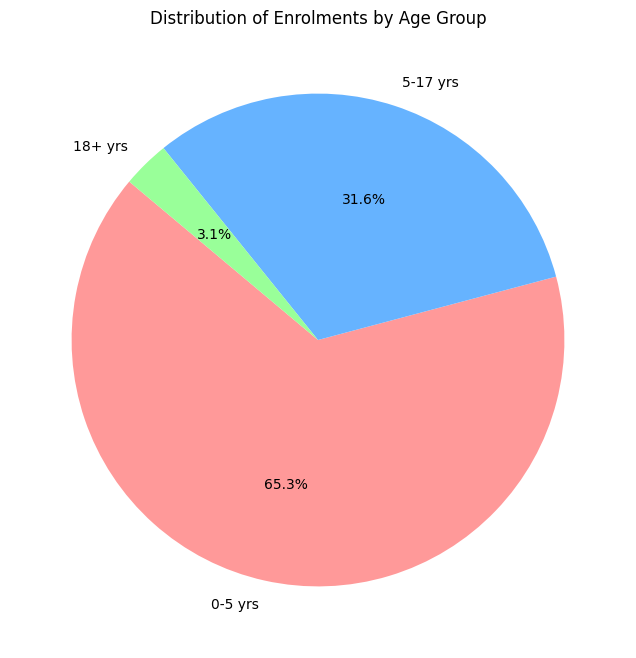

In [15]:
# Fix the date format and rerun analysis
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['month'] = df['date'].dt.to_period('M')

# Total enrolments
df['total_enrolments'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']

# 1. Temporal Trend - Monthly Total Enrolments
monthly_trend = df.groupby('month')['total_enrolments'].sum()

# 2. State-wise Total Enrolments
state_enrolments = df.groupby('state')['total_enrolments'].sum().sort_values(ascending=False)

# 3. Demographic distribution
demographics = df[['age_0_5', 'age_5_17', 'age_18_greater']].sum()

# 4. Anomalies - Checking for records with very high total enrolments (Outliers)
# Let's see the top 10 individual records
anomalies = df.sort_values(by='total_enrolments', ascending=False).head(10)

# Save Plots
plt.figure(figsize=(10, 5))
monthly_trend.plot(kind='line', marker='o', color='royalblue')
plt.title('Monthly Aadhaar Enrolment Trend (2025)')
plt.xlabel('Month')
plt.ylabel('Total Enrolments')
plt.grid(True)
plt.tight_layout()
plt.savefig('monthly_trend.png')

plt.figure(figsize=(12, 6))
state_enrolments.head(10).plot(kind='bar', color='seagreen')
plt.title('Top 10 States by Aadhaar Enrolments')
plt.xlabel('State')
plt.ylabel('Total Enrolments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_states.png')

plt.figure(figsize=(8, 8))
plt.pie(demographics, labels=['0-5 yrs', '5-17 yrs', '18+ yrs'], autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribution of Enrolments by Age Group')
plt.savefig('demographics_pie.png')

# Output summaries
print("Monthly Trends:\n", monthly_trend)
print("\nTop 5 States:\n", state_enrolments.head(5))
print("\nDemographic Sums:\n", demographics)
print("\nPotential Anomalous Records (Highest single-day/pincode enrolments):")
print(anomalies[['date', 'state', 'district', 'pincode', 'total_enrolments']])

In [16]:
# District-wise breakdown for the top state (Uttar Pradesh)
up_districts = df[df['state'] == 'Uttar Pradesh'].groupby('district')['total_enrolments'].sum().sort_values(ascending=False).head(10)

# Pincodes with highest density of 0-5 enrolments
pincode_0_5 = df.groupby(['pincode', 'district', 'state'])['age_0_5'].sum().sort_values(ascending=False).head(10)

print("Top 10 Districts in Uttar Pradesh:\n", up_districts)
print("\nTop 10 Pincodes for Child Enrolment (0-5):\n", pincode_0_5)

# Calculate Average Enrolments per Pincode in each state to find 'High Traffic' states
avg_pincode_traffic = df.groupby('state')['total_enrolments'].mean().sort_values(ascending=False).head(10)
print("\nStates with Highest Average Enrolment per Entry:\n", avg_pincode_traffic)

Top 10 Districts in Uttar Pradesh:
 district
Bahraich        39338
Sitapur         30854
Agra            29910
Bareilly        27811
Aligarh         26192
Lucknow         25514
Hardoi          25193
Kanpur Nagar    24708
Kheri           24578
Shahjahanpur    24291
Name: total_enrolments, dtype: int64

Top 10 Pincodes for Child Enrolment (0-5):
 pincode  district          state        
244001   Moradabad         Uttar Pradesh    10516
110059   West Delhi        Delhi             7297
247001   Saharanpur        Uttar Pradesh     7142
121004   Faridabad         Haryana           6399
202001   Aligarh           Uttar Pradesh     6296
244901   Rampur            Uttar Pradesh     5853
431001   Aurangabad        Maharashtra       5765
250002   Meerut            Uttar Pradesh     5722
421302   Thane             Maharashtra       5138
110094   North East Delhi  Delhi             4928
Name: age_0_5, dtype: int64

States with Highest Average Enrolment per Entry:
 state
Jammu And Kashmir          

Anomalous Dates (Potential Special Drives): [Timestamp('2025-04-01 00:00:00'), Timestamp('2025-06-01 00:00:00'), Timestamp('2025-07-01 00:00:00')]

Top Active Pincodes (Resource Allocation Zones):
 state          pincode
Uttar Pradesh  244001     15124
               202001     11842
Meghalaya      793119     11720
Delhi          110059     10462
Uttar Pradesh  247001     10189
               244901      9572
               250002      9378
Maharashtra    431001      9104
Uttar Pradesh  282001      8686
               242001      8511
Name: total, dtype: int64


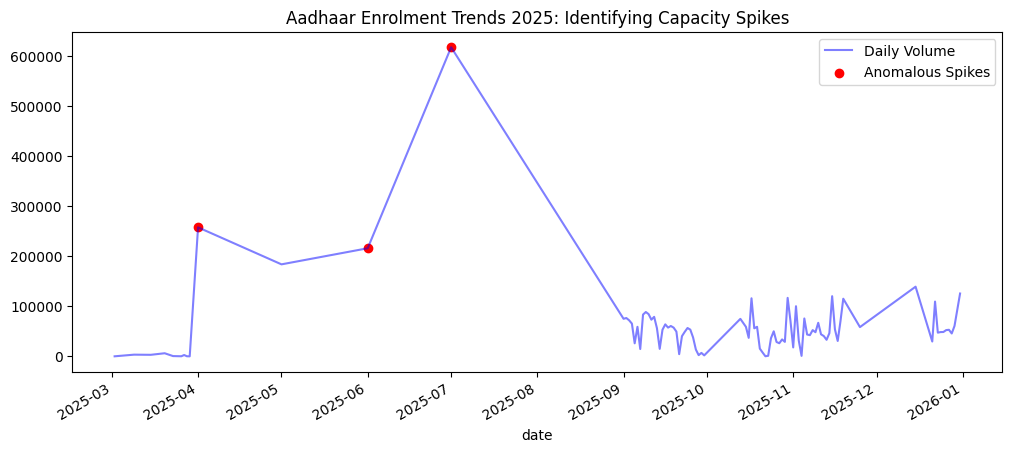

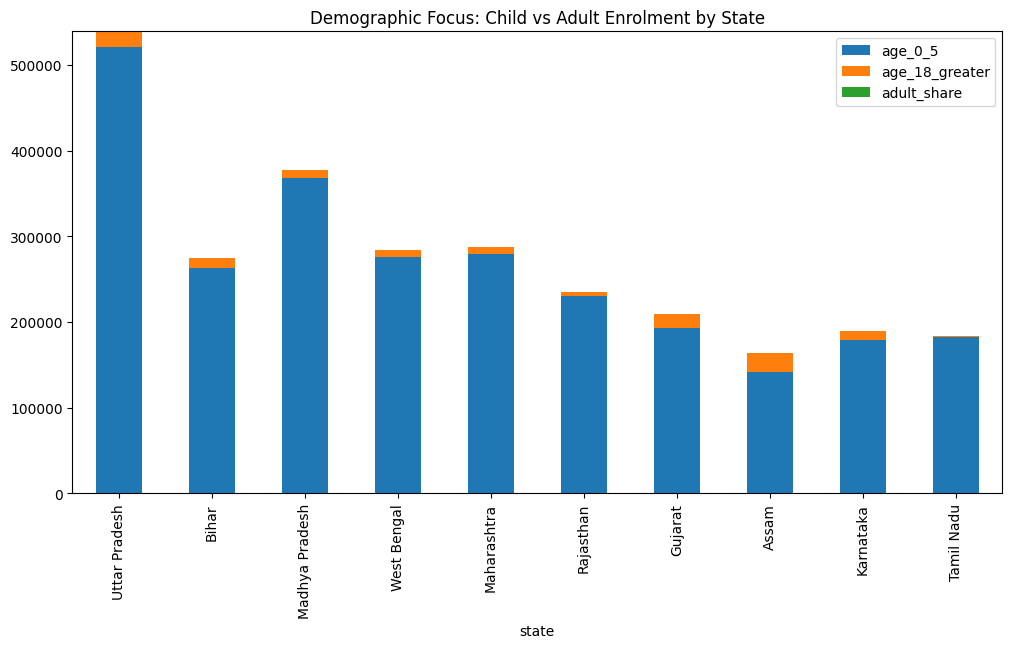

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Clean
files = ['api_data_aadhar_enrolment_0_500000.csv', 
         'api_data_aadhar_enrolment_500000_1000000.csv', 
         'api_data_aadhar_enrolment_1000000_1006029.csv']
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Correcting Date & creating features
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['month_year'] = df['date'].dt.to_period('M')
df['total'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']

# --- A. ACTIONABLE INSIGHT: SEASONALITY & SPIKES ---
daily_vol = df.groupby('date')['total'].sum()
mean_v, std_v = daily_vol.mean(), daily_vol.std()
spikes = daily_vol[daily_vol > (mean_v + 2*std_v)]

# --- B. ACTIONABLE INSIGHT: SATURATION ANALYSIS ---
# Calculate % of adult vs child enrolments per state
state_mix = df.groupby('state')[['age_0_5', 'age_18_greater']].sum()
state_mix['adult_share'] = (state_mix['age_18_greater'] / (state_mix['age_0_5'] + state_mix['age_18_greater'])) * 100

# --- C. ACTIONABLE INSIGHT: HIGH-TRAFFIC PINCODES ---
pincode_activity = df.groupby(['state', 'pincode'])['total'].sum().sort_values(ascending=False).head(10)

# --- VISUALIZATIONS ---
# 1. Trend with Spike Highlight
plt.figure(figsize=(12, 5))
daily_vol.plot(color='blue', alpha=0.5, label='Daily Volume')
plt.scatter(spikes.index, spikes.values, color='red', label='Anomalous Spikes')
plt.title('Aadhaar Enrolment Trends 2025: Identifying Capacity Spikes')
plt.legend()
plt.savefig('trends_with_spikes.png')

# 2. Child vs Adult Enrolment Focus
top_states = df.groupby('state')['total'].sum().nlargest(10).index
state_mix.loc[top_states].plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Demographic Focus: Child vs Adult Enrolment by State')
plt.savefig('demographic_focus.png')

print("Anomalous Dates (Potential Special Drives):", spikes.index.tolist())
print("\nTop Active Pincodes (Resource Allocation Zones):\n", pincode_activity)

